# 05 - Non-recurrent Autoencoder (Step 5)

**Purpose:** the nonlinear reconstruction corner of the five-method
comparison. A small feed-forward autoencoder is trained to rebuild ordinary
6-hour windows of a sensor's own history, and whatever it rebuilds badly is
scored as anomalous. It writes the schema Step 3 established
(`uema.detect.SCHEMA_COLUMNS`), so Step 7 can align it against the
statistical and density/isolation detectors already on disk.

The architecture is deliberately **non-recurrent** — no LSTM/GRU/RNN layer
anywhere, and the window arrives flattened, so the network cannot know its
inputs are ordered in time. That withheld property is the point: Step 6 will
give the identical windows to recurrent models, so Step 7 can read any
difference between the two as the contribution of modelling temporal order,
rather than as the contribution of reconstruction-based scoring in general.

Nothing here is validated against ground truth — this project has no labels.
This is one more comparable input to Step 7.

Beyond the detector itself, this notebook runs three robustness passes, two
of them adapted from the prior prototype's experimental design (four
bottleneck sizes, five seeds) with its label-dependent metrics replaced by
the self-agreement statistic Step 4b established:

1. **Bottleneck ablation** — how much the flagged set moves with latent size.
2. **Seed stability** — how much it moves with initialization alone.
3. **Window control** — the self-agreement control the plan requires of this
   step, mirroring Step 4b.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from uema.agree import align_scores, jaccard_by_sensor, jaccard_matrix, native_flags
from uema.detect import SCHEMA_COLUMNS, build_detection_table
from uema.reconstruct import (
    BOTTLENECK,
    BOTTLENECK_GRID,
    CONTROL_BINS,
    SEEDS,
    SEQUENCE_BINS,
    THRESHOLD_GRID,
    DenseAutoencoder,
    bottleneck_for,
    percentile_threshold,
    reconstruction_error,
    scale_windows,
    sliding_windows,
    time_split,
    train_reconstructor,
)
from uema.silver import consolidate_stations, fill_gaps
from uema.style import PALETTE, PALETTE_ORDER, apply_style, pretty_label

apply_style()
torch.set_num_threads(4)

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

REPORT_DIR = Path("..") / "reports" / "data_audit"
DETECT_DIR = Path("..") / "reports" / "detections"
DETECT_DIR.mkdir(parents=True, exist_ok=True)

## Data prep

Identical to Steps 1-4: the same 12 in-scope stations (GO + CONDITIONAL-GO,
read from `station_recommendation.csv`, never hardcoded), each on its own
joint-span 10-minute grid with short gaps (<=6h) linearly bridged and longer
gaps left as `NaN`. Sharing the prepared data with the other detectors is
what makes Step 7's per-timestamp comparison meaningful — a difference
between methods then reflects the methods, not different preprocessing.

In [2]:
recommendation = pd.read_csv(
    REPORT_DIR / "station_recommendation.csv", index_col="station"
)
station_frames = consolidate_stations(recommendation)
station_frames = {
    station: fill_gaps(df.resample("10min").mean(), max_gap="6h")
    for station, df in station_frames.items()
}
sorted(station_frames)

['recinto-esparza',
 'recinto-santa-cruz',
 'sede-atlantico_turrialba',
 'sede-caribe_limon',
 'sede-central_finca-1',
 'sede-central_finca-2',
 'sede-central_finca-3',
 'sede-central_losic-norte-1',
 'sede-central_losic-norte-2',
 'sede-central_sabanilla',
 'sede-guanacaste_liberia',
 'sede-sur_golfito']

## Methodology

**Window: 36 bins (6h), centered, stride 1.** Not a free parameter. Step 4b
re-ran the density methods at 6h instead of their native 1h and changed
nothing else; each method's agreement with *itself* fell to 0.053 (LOF) and
0.242 (Isolation Forest), so window length moves a flagged set as much as
method family does. 6h matches Step 3's rolling window, keeping the project
at two time scales rather than three, and gives Step 6's recurrent models
enough sequence for recurrence to have something to model. Step 6 must use
this same length or the comparison it exists for measures the window instead.

**Input: the flattened raw window**, not Step 4's 4-dimensional window
summaries. Step 6's recurrent models must see the actual sequence; giving
Step 5 the identical numbers in flattened form is what isolates recurrence.
Reusing Step 4's summary features instead would confound representation with
recurrence — the same class of error Step 4b caught for window length.

**Fit per station x sensor**, as in Steps 3-4, so a Step 7 disagreement
reflects the method and not a change in fitting scope, and "anomalous" keeps
meaning anomalous for that station rather than relative to a network-wide
pool. A window containing any `NaN` is dropped rather than imputed, the same
completeness rule `uema.density.window_features` applies.

**Architecture:** `36 -> hidden -> latent -> hidden -> 36`, ReLU, linear
output, with the hidden width at the geometric mean of the input and latent
sizes so the funnel stays even at any window length. The latent is 8 at the
primary window (4.5:1 compression); the window control holds that ratio
rather than the absolute size, because at 6 inputs a latent of 8 would be
over-complete and an autoencoder that can copy its input scores nothing.

**Training:** Adam, MSE, batch 256, early stopping on validation loss with
the best state restored. The split is the earliest 80% of each cell's span by
time, never random — consecutive 10-minute readings are strongly dependent,
so random assignment would put a window's near-duplicate neighbours on the
other side of the split. `RobustScaler` is fit on training rows only.

**Threshold: the 99th percentile of the validation split's reconstruction
error**, per station x sensor, with the 90th and 95th reported alongside.
Worth stating plainly, since it is an asymmetry Step 7 has to handle:
`|z| > 3`, `LOF > 1.5` and `s(x, n) > 0.5` are published conventions that let
the data decide how much gets flagged, while a percentile fixes the alarm
rate by construction. This method's native flagged rate is therefore not
comparable to the others' the way theirs are to each other.

**Timestamp: the window center**, following pandas' `rolling(center=True)`
convention, matching Steps 3 and 4 so Step 7 can align on the timestamp.

## Fitting

Nine runs per station x sensor — the four bottleneck sizes at seed 0, the
primary bottleneck at four further seeds, and the window control — so 324
models in total. Each is small and trains in seconds; the whole cell takes
on the order of an hour. Every run is stored so the passes below derive from
one fitting pass rather than refitting.

In [3]:
SENSORS = ("pressure", "precipitation", "luminous_intensity")

PRIMARY = (SEQUENCE_BINS, BOTTLENECK, 0)
CONTROL = (CONTROL_BINS, bottleneck_for(CONTROL_BINS), 0)
RUNS = (
    [(SEQUENCE_BINS, d, 0) for d in BOTTLENECK_GRID]
    + [(SEQUENCE_BINS, BOTTLENECK, seed) for seed in SEEDS if seed != 0]
    + [CONTROL]
)


def fit_cell(series: pd.Series, window: int, bottleneck: int, seed: int) -> dict | None:
    """Train one autoencoder on one station x sensor and score every window."""
    matrix, centers = sliding_windows(series, window)
    if len(matrix) == 0:
        return None

    train_mask = time_split(centers)
    scaled = scale_windows(matrix, train_mask)
    model = DenseAutoencoder(window, bottleneck)
    history = train_reconstructor(model, scaled, train_mask, seed=seed)
    score = reconstruction_error(model, scaled, centers)

    return {
        "score": score,
        "threshold": percentile_threshold(score, train_mask),
        "train_mask": train_mask,
        "n_train": int(train_mask.sum()),
        "n_scored": int(len(score)),
        "epochs": len(history["train"]),
        "best_val": float(np.nanmin(history["val"])),
    }


results = {}
for station, df10 in sorted(station_frames.items()):
    for sensor in SENSORS:
        for window, bottleneck, seed in RUNS:
            fit = fit_cell(df10[sensor], window, bottleneck, seed)
            if fit is not None:
                results[(station, sensor, window, bottleneck, seed)] = fit
    print(f"{station:<32} {len(results):>4} runs done", flush=True)

len(results)

recinto-esparza                    27 runs done


recinto-santa-cruz                 54 runs done


sede-atlantico_turrialba           81 runs done


sede-caribe_limon                 108 runs done


sede-central_finca-1              135 runs done


...

sede-central_losic-norte-2        243 runs done


sede-central_sabanilla            270 runs done


sede-guanacaste_liberia           297 runs done


sede-sur_golfito                  324 runs done


324

### Did every cell actually train?

Two ways a fit can be quietly wrong rather than loudly broken.

The prior prototype's data-scarcity failure mode was a model that produced
all-zero output where training windows were too few (under ~1,650) — a
detector that silently degenerates rather than erroring. The assertion below
catches that.

The second is a model cut off mid-convergence. `MAX_EPOCHS` is meant to be a
safety bound that early stopping reaches first, so a run that ends by
exhausting it was still learning when training stopped. The `ended_early`
column reports which rule ended each run; if a meaningful share hit the cap,
the cap — not convergence — is setting what these scores are, and the budget
needs raising rather than the results interpreting.


In [4]:
from uema.reconstruct import MAX_EPOCHS

fit_health = pd.DataFrame(
    [
        {
            "station": station,
            "sensor": sensor,
            "n_train": fit["n_train"],
            "n_scored": fit["n_scored"],
            "epochs": fit["epochs"],
            "ended_early": fit["epochs"] < MAX_EPOCHS,
            "best_val_loss": fit["best_val"],
            "score_std": float(fit["score"].std()),
            "threshold": fit["threshold"],
        }
        for (station, sensor, window, bottleneck, seed), fit in results.items()
        if (window, bottleneck, seed) == PRIMARY
    ]
)

assert (fit_health["score_std"] > 0).all(), "a cell produced a constant score vector"

capped = (~fit_health["ended_early"]).sum()
print(f"ended by early stopping: {fit_health['ended_early'].sum()}/{len(fit_health)}")
print(f"hit the {MAX_EPOCHS}-epoch cap:  {capped}/{len(fit_health)}")
print(fit_health["epochs"].describe().round(1).to_string())

fit_health.sort_values("epochs", ascending=False).head(8)


ended by early stopping: 36/36
hit the 500-epoch cap:  0/36
count     36.0
mean     111.5
std       61.4
min       24.0
25%       72.0
50%       97.0
75%      142.2
max      293.0


,station,sensor,n_train,n_scored,epochs,ended_early,best_val_loss,score_std,threshold
27,sede-central_sabanilla,pressure,12268,15389,293,True,0.002495,0.001576,0.011861
25,sede-central_losic-norte-2,precipitation,15732,20745,238,True,0.028627,0.107002,1.037639
1,recinto-esparza,precipitation,72822,91028,223,True,0.021293,0.144317,0.641060
13,sede-central_finca-1,precipitation,32259,40324,188,True,0.004751,0.033103,0.100687
28,sede-central_sabanilla,precipitation,12483,15604,176,True,0.013462,0.076671,0.502162
9,sede-caribe_limon,pressure,26440,30450,171,True,0.001693,0.001127,0.008622
12,sede-central_finca-1,pressure,30376,38371,170,True,0.000559,0.000525,0.003022
20,sede-central_finca-3,luminous_intensity,37022,52751,166,True,0.052218,0.087836,0.425440


## Primary detection table

The delivered method: 6h window, latent 8, seed 0, flagged above the 99th
percentile of each cell's validation reconstruction error.

In [5]:
detections = pd.concat(
    [
        build_detection_table(fit["score"], station, sensor, "autoencoder", fit["threshold"])
        for (station, sensor, window, bottleneck, seed), fit in results.items()
        if (window, bottleneck, seed) == PRIMARY
    ],
    ignore_index=True,
)
assert list(detections.columns) == SCHEMA_COLUMNS
detections.to_parquet(DETECT_DIR / "step5_autoencoder.parquet", index=False)
detections.shape

(1911399, 6)

In [6]:
summary = (
    detections.groupby(["station", "sensor", "method"])
    .agg(n_scored=("flagged", "size"), n_flagged=("flagged", "sum"))
    .assign(flagged_rate=lambda d: d["n_flagged"] / d["n_scored"])
    .reset_index()
    .merge(fit_health[["station", "sensor", "n_train", "epochs", "ended_early", "best_val_loss"]], on=["station", "sensor"])
)
summary.to_csv(DETECT_DIR / "step5_summary.csv", index=False)

summary.pivot_table(index="station", columns="sensor", values="flagged_rate")

sensor,luminous_intensity,precipitation,pressure
station,,,
recinto-esparza,0.008936,0.009678,0.008765
recinto-santa-cruz,0.012831,0.010728,0.023285
sede-atlantico_turrialba,0.012807,0.004230,0.006356
sede-caribe_limon,0.003350,0.005340,0.003547
sede-central_finca-1,0.008757,0.010515,0.005264
sede-central_finca-2,0.007750,0.010874,0.021552
sede-central_finca-3,0.007185,0.015777,0.003147
sede-central_losic-norte-1,0.012082,0.026770,0.009910
sede-central_losic-norte-2,0.039879,0.003278,0.004021


## Threshold sensitivity

The cutoff percentile is a choice with no label to justify it, so the flagged
rate is reported at three of them rather than presenting one as validated —
the same device Steps 4 and 6 use. Because the cutoff is a quantile of the
validation split alone, the resulting rate over *all* rows is not mechanically
equal to `1 - pct`; how far it departs is itself informative, since it says
whether the later part of a record reconstructs like the earlier part.

In [7]:
sensitivity_rows = []
for (station, sensor, window, bottleneck, seed), fit in results.items():
    if (window, bottleneck, seed) != PRIMARY:
        continue
    for pct in THRESHOLD_GRID:
        cutoff = percentile_threshold(fit["score"], fit["train_mask"], pct)
        sensitivity_rows.append(
            {
                "station": station,
                "sensor": sensor,
                "percentile": pct,
                "cutoff": cutoff,
                "rate_overall": float((fit["score"] > cutoff).mean()),
            }
        )

threshold_sensitivity = pd.DataFrame(sensitivity_rows)
threshold_sensitivity.to_csv(DETECT_DIR / "step5_threshold_sensitivity.csv", index=False)

threshold_sensitivity.pivot_table(
    index="sensor", columns="percentile", values="rate_overall"
)

percentile,0.90,0.95,0.99
sensor,,,
luminous_intensity,0.103125,0.051395,0.012063
precipitation,0.086762,0.044107,0.010559
pressure,0.073961,0.037338,0.009169


## Robustness pass 1 — bottleneck ablation

Four latent sizes over the same windows, seed held at 0. The prior prototype
swept four bottleneck sizes and found results stable across the smaller three
but bimodal and seed-sensitive at the largest where training data was scarce.
It could measure that against labels; this project cannot, so the question
becomes the one Step 4b established — **how far does the flagged set move** —
answered with the same `uema.agree` primitives Step 7 will use.

Each variant is treated as its own "method" so the agreement code applies
unchanged. Flags are each variant's own 99th-percentile cutoff, which is an
equal alarm budget by construction, so these numbers need no separate
matched-budget view.

In [8]:
def variant_table(method_of, keep) -> pd.DataFrame:
    """Long-form detection table over a set of runs, one `method` per variant."""
    return pd.concat(
        [
            build_detection_table(fit["score"], station, sensor, method_of(key), fit["threshold"])
            for key, fit in results.items()
            for station, sensor in [key[:2]]
            if keep(key)
        ],
        ignore_index=True,
    )


bottleneck_runs = variant_table(
    lambda key: f"latent_{key[3]}",
    lambda key: key[2] == SEQUENCE_BINS and key[4] == 0,
)
bottleneck_flags = native_flags(bottleneck_runs, align_scores(bottleneck_runs).index)
bottleneck_jaccard = jaccard_matrix(bottleneck_flags)
bottleneck_jaccard

,latent_16,latent_2,latent_4,latent_8
latent_16,1.000000,0.176868,0.354096,0.531135
latent_2,0.176868,1.000000,0.259245,0.200556
latent_4,0.354096,0.259245,1.000000,0.449078
latent_8,0.531135,0.200556,0.449078,1.000000


In [9]:
bottleneck_ablation = (
    jaccard_by_sensor(bottleneck_flags)
    .assign(comparison="bottleneck")
    .merge(
        bottleneck_flags.groupby(level="sensor").mean().stack().rename("flagged_rate_b"),
        left_on=["sensor", "method_b"],
        right_index=True,
    )
)
bottleneck_ablation.to_csv(DETECT_DIR / "step5_bottleneck_ablation.csv", index=False)

bottleneck_ablation[bottleneck_ablation["method_a"] == f"latent_{BOTTLENECK}"].pivot_table(
    index="sensor", columns="method_b", values="jaccard"
)

method_b
sensor


## Robustness pass 2 — seed stability

The same architecture five times over, differing only in weight
initialization and batch order. This is the pass the prior prototype's
ablation most directly motivates: it found seed sensitivity, not architecture
choice, to be what destabilized its results where data was thin, which is
precisely what a single fixed `random_state` — the reproducibility device
Step 4 uses for Isolation Forest — would conceal in a neural network.

A method whose flagged set is not stable under reseeding cannot support a
Step 7 claim about method families, so this number bounds how much of the
Step 5 result is about autoencoders at all.

In [10]:
seed_runs = variant_table(
    lambda key: f"seed_{key[4]}",
    lambda key: key[2] == SEQUENCE_BINS and key[3] == BOTTLENECK,
)
seed_flags = native_flags(seed_runs, align_scores(seed_runs).index)
seed_pairs = jaccard_by_sensor(seed_flags)

seed_stability = (
    seed_pairs.groupby("sensor")["jaccard"]
    .agg(mean_pairwise_jaccard="mean", min_pairwise_jaccard="min", n_pairs="size")
    .join(
        seed_flags.groupby(level="sensor")
        .mean()
        .agg(["mean", "std"], axis=1)
        .rename(columns={"mean": "flagged_rate_mean", "std": "flagged_rate_std"})
    )
    .reset_index()
)
seed_stability.to_csv(DETECT_DIR / "step5_seed_stability.csv", index=False)
seed_stability

,sensor,mean_pairwise_jaccard,min_pairwise_jaccard,n_pairs,flagged_rate_mean,flagged_rate_std
0,luminous_intensity,0.601331,0.511218,10,0.011217,0.000166
1,precipitation,0.776337,0.768891,10,0.010196,0.000138
2,pressure,0.583005,0.546776,10,0.010814,0.000592


## Robustness pass 3 — window control

The control the revised plan requires of this step, run exactly as Step 4b
ran it on the density methods: refit at a second window length, change
nothing else, and report the method's agreement **with itself**. Step 4b's
values are the reference points — LOF 0.053, Isolation Forest 0.242 — and
whatever this method scores is what Step 7 must weigh any Step 5 vs Step 6
difference against.

The control window is 1h, which is also Step 4's window, so this doubles as a
window-matched comparison against LOF and Isolation Forest. Compression is
held at 4.5:1 rather than the latent size at 8, so the window is the only
thing that varies; at 6 inputs a latent of 8 would be over-complete and the
model could simply copy its input.

In [11]:
window_runs = variant_table(
    lambda key: f"window_{key[2]}",
    lambda key: key[4] == 0 and (key[2], key[3], key[4]) in (PRIMARY, CONTROL),
)
window_flags = native_flags(window_runs, align_scores(window_runs).index)

window_control = jaccard_by_sensor(window_flags)
window_control.loc[len(window_control)] = {
    "sensor": "all",
    "method_a": f"window_{SEQUENCE_BINS}",
    "method_b": f"window_{CONTROL_BINS}",
    "jaccard": jaccard_matrix(window_flags).iloc[0, 1],
}
window_control.to_csv(DETECT_DIR / "step5_window_control.csv", index=False)
window_control

,sensor,method_a,method_b,jaccard
0,luminous_intensity,window_36,window_6,0.053407
1,precipitation,window_36,window_6,0.209952
2,pressure,window_36,window_6,0.171500
3,all,window_36,window_6,0.127743


## Sanity-check plots

The most confidently-flagged window per sensor, plotted in its surrounding
context — a check that the detector is picking up genuinely irregular
episodes rather than a systematic artifact (every gap edge, every sunrise)
before this table is trusted as an input to Step 7.

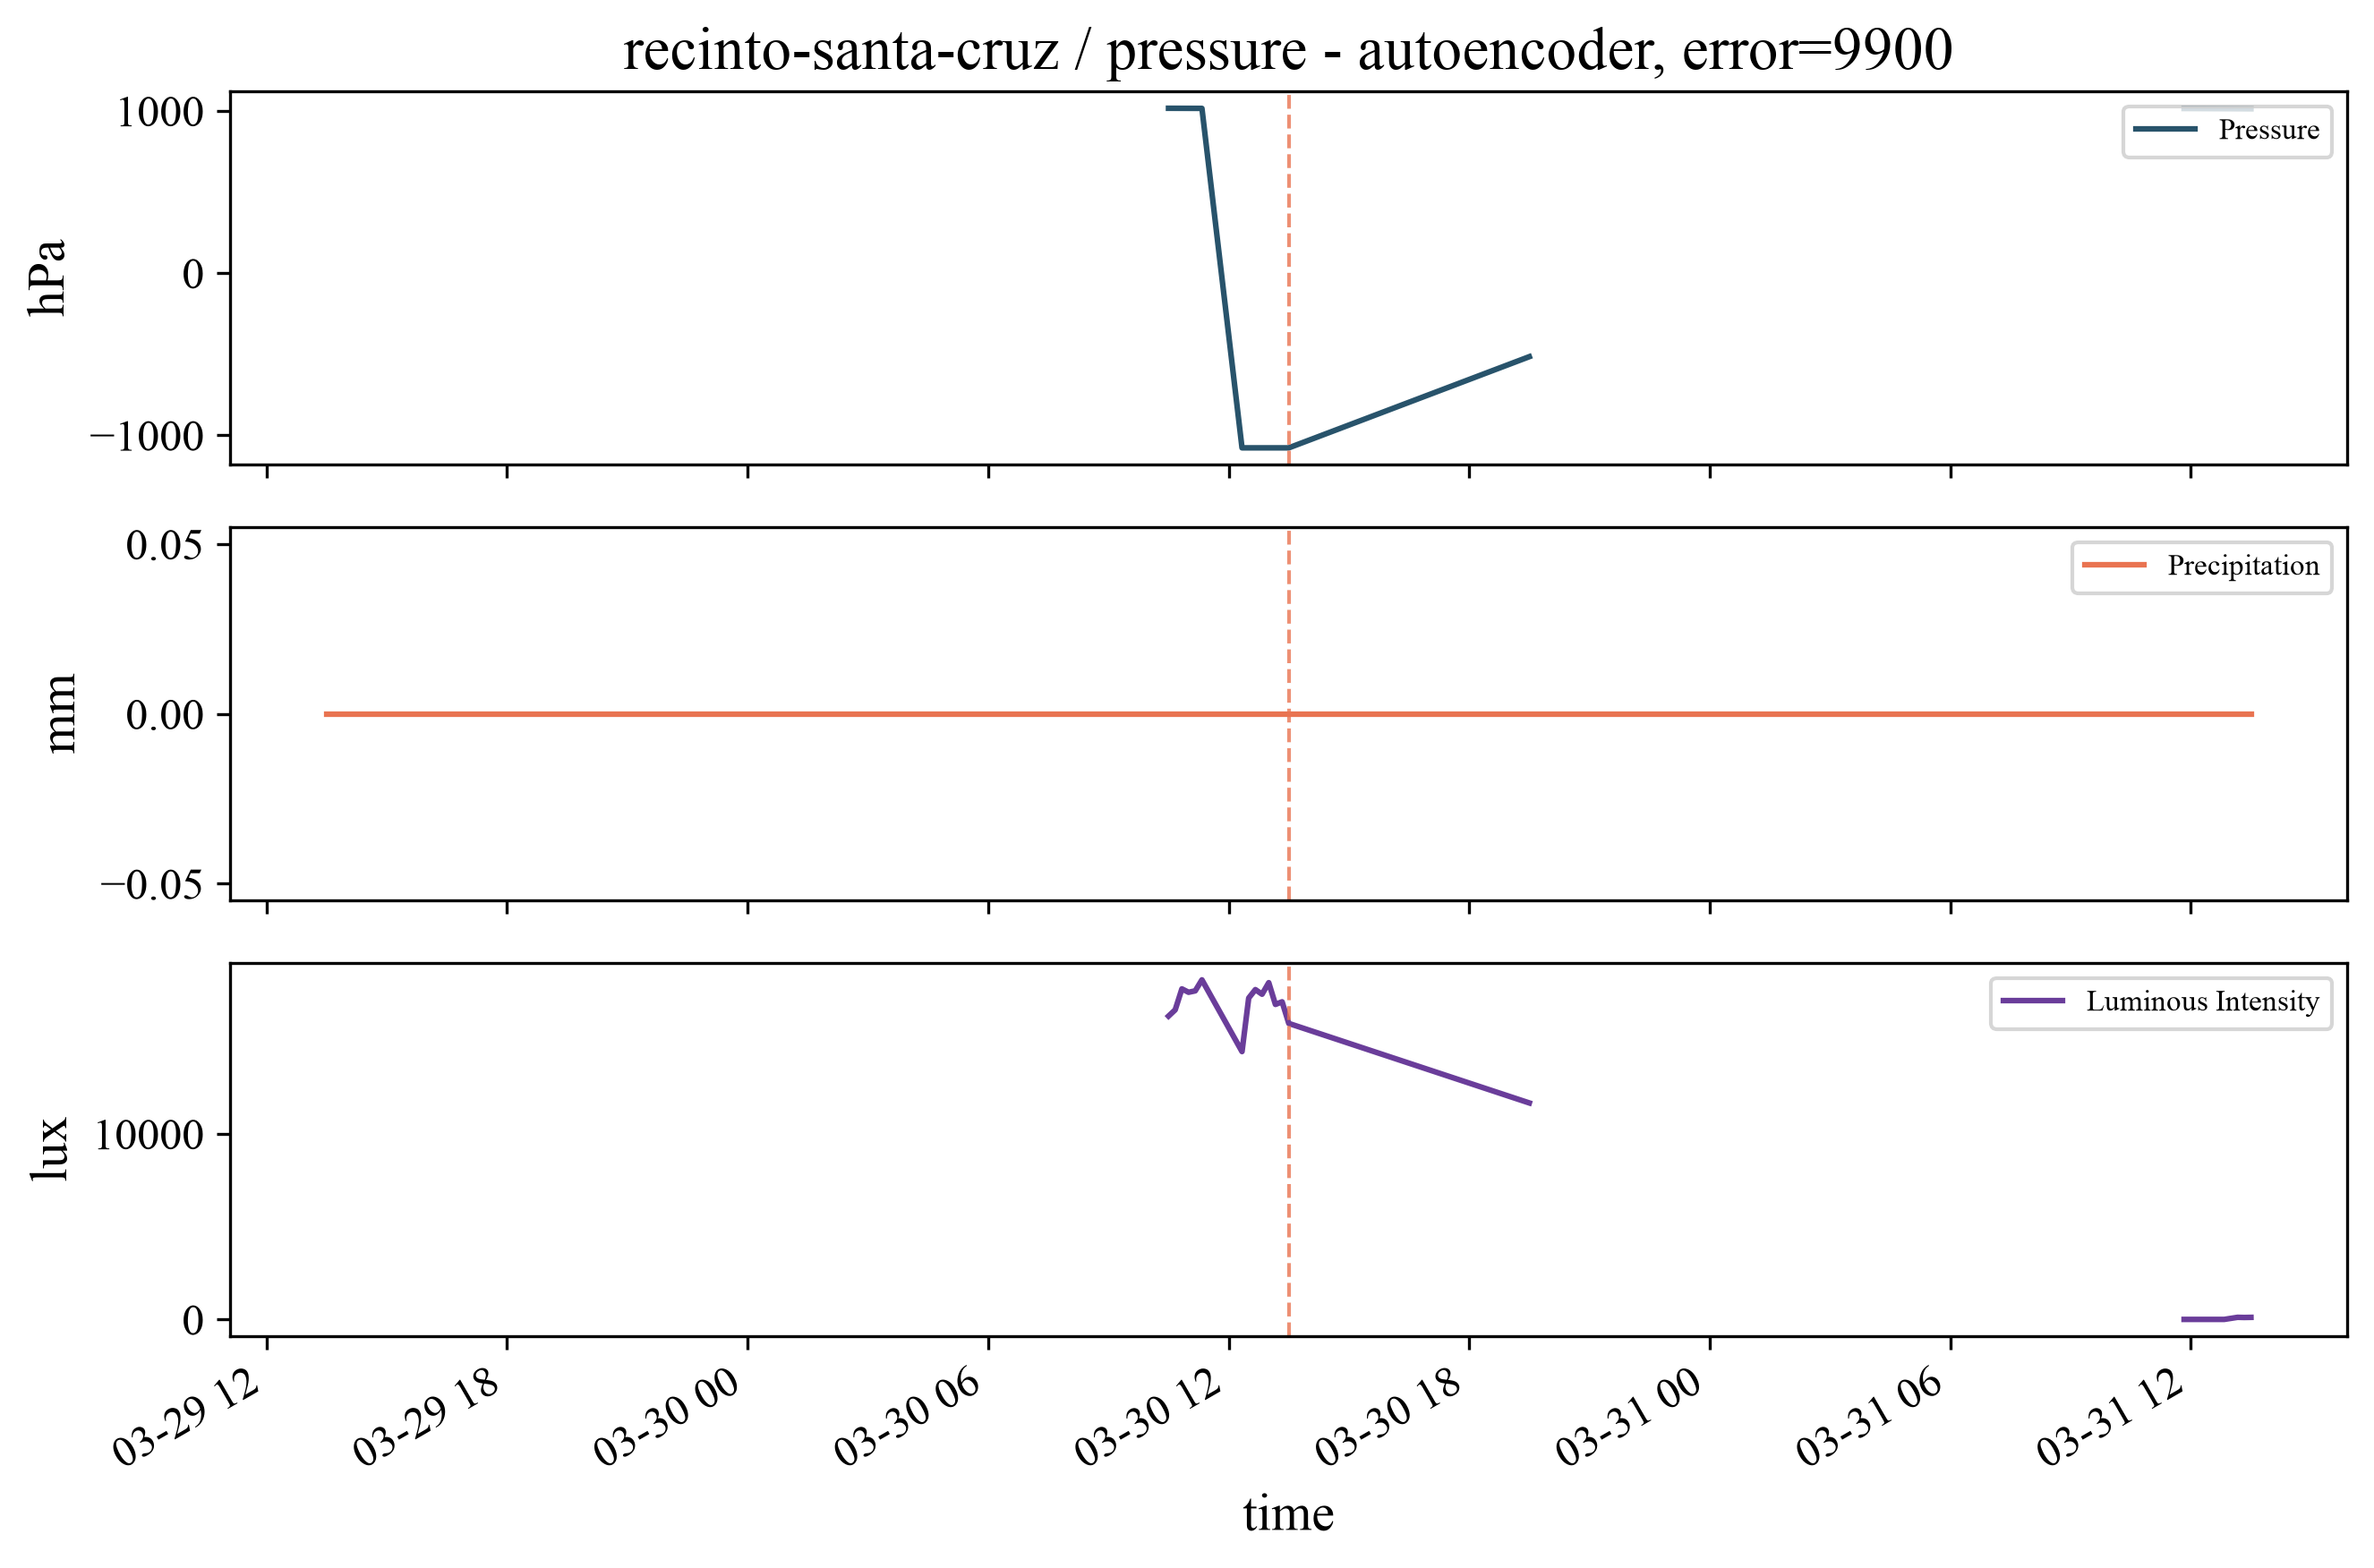

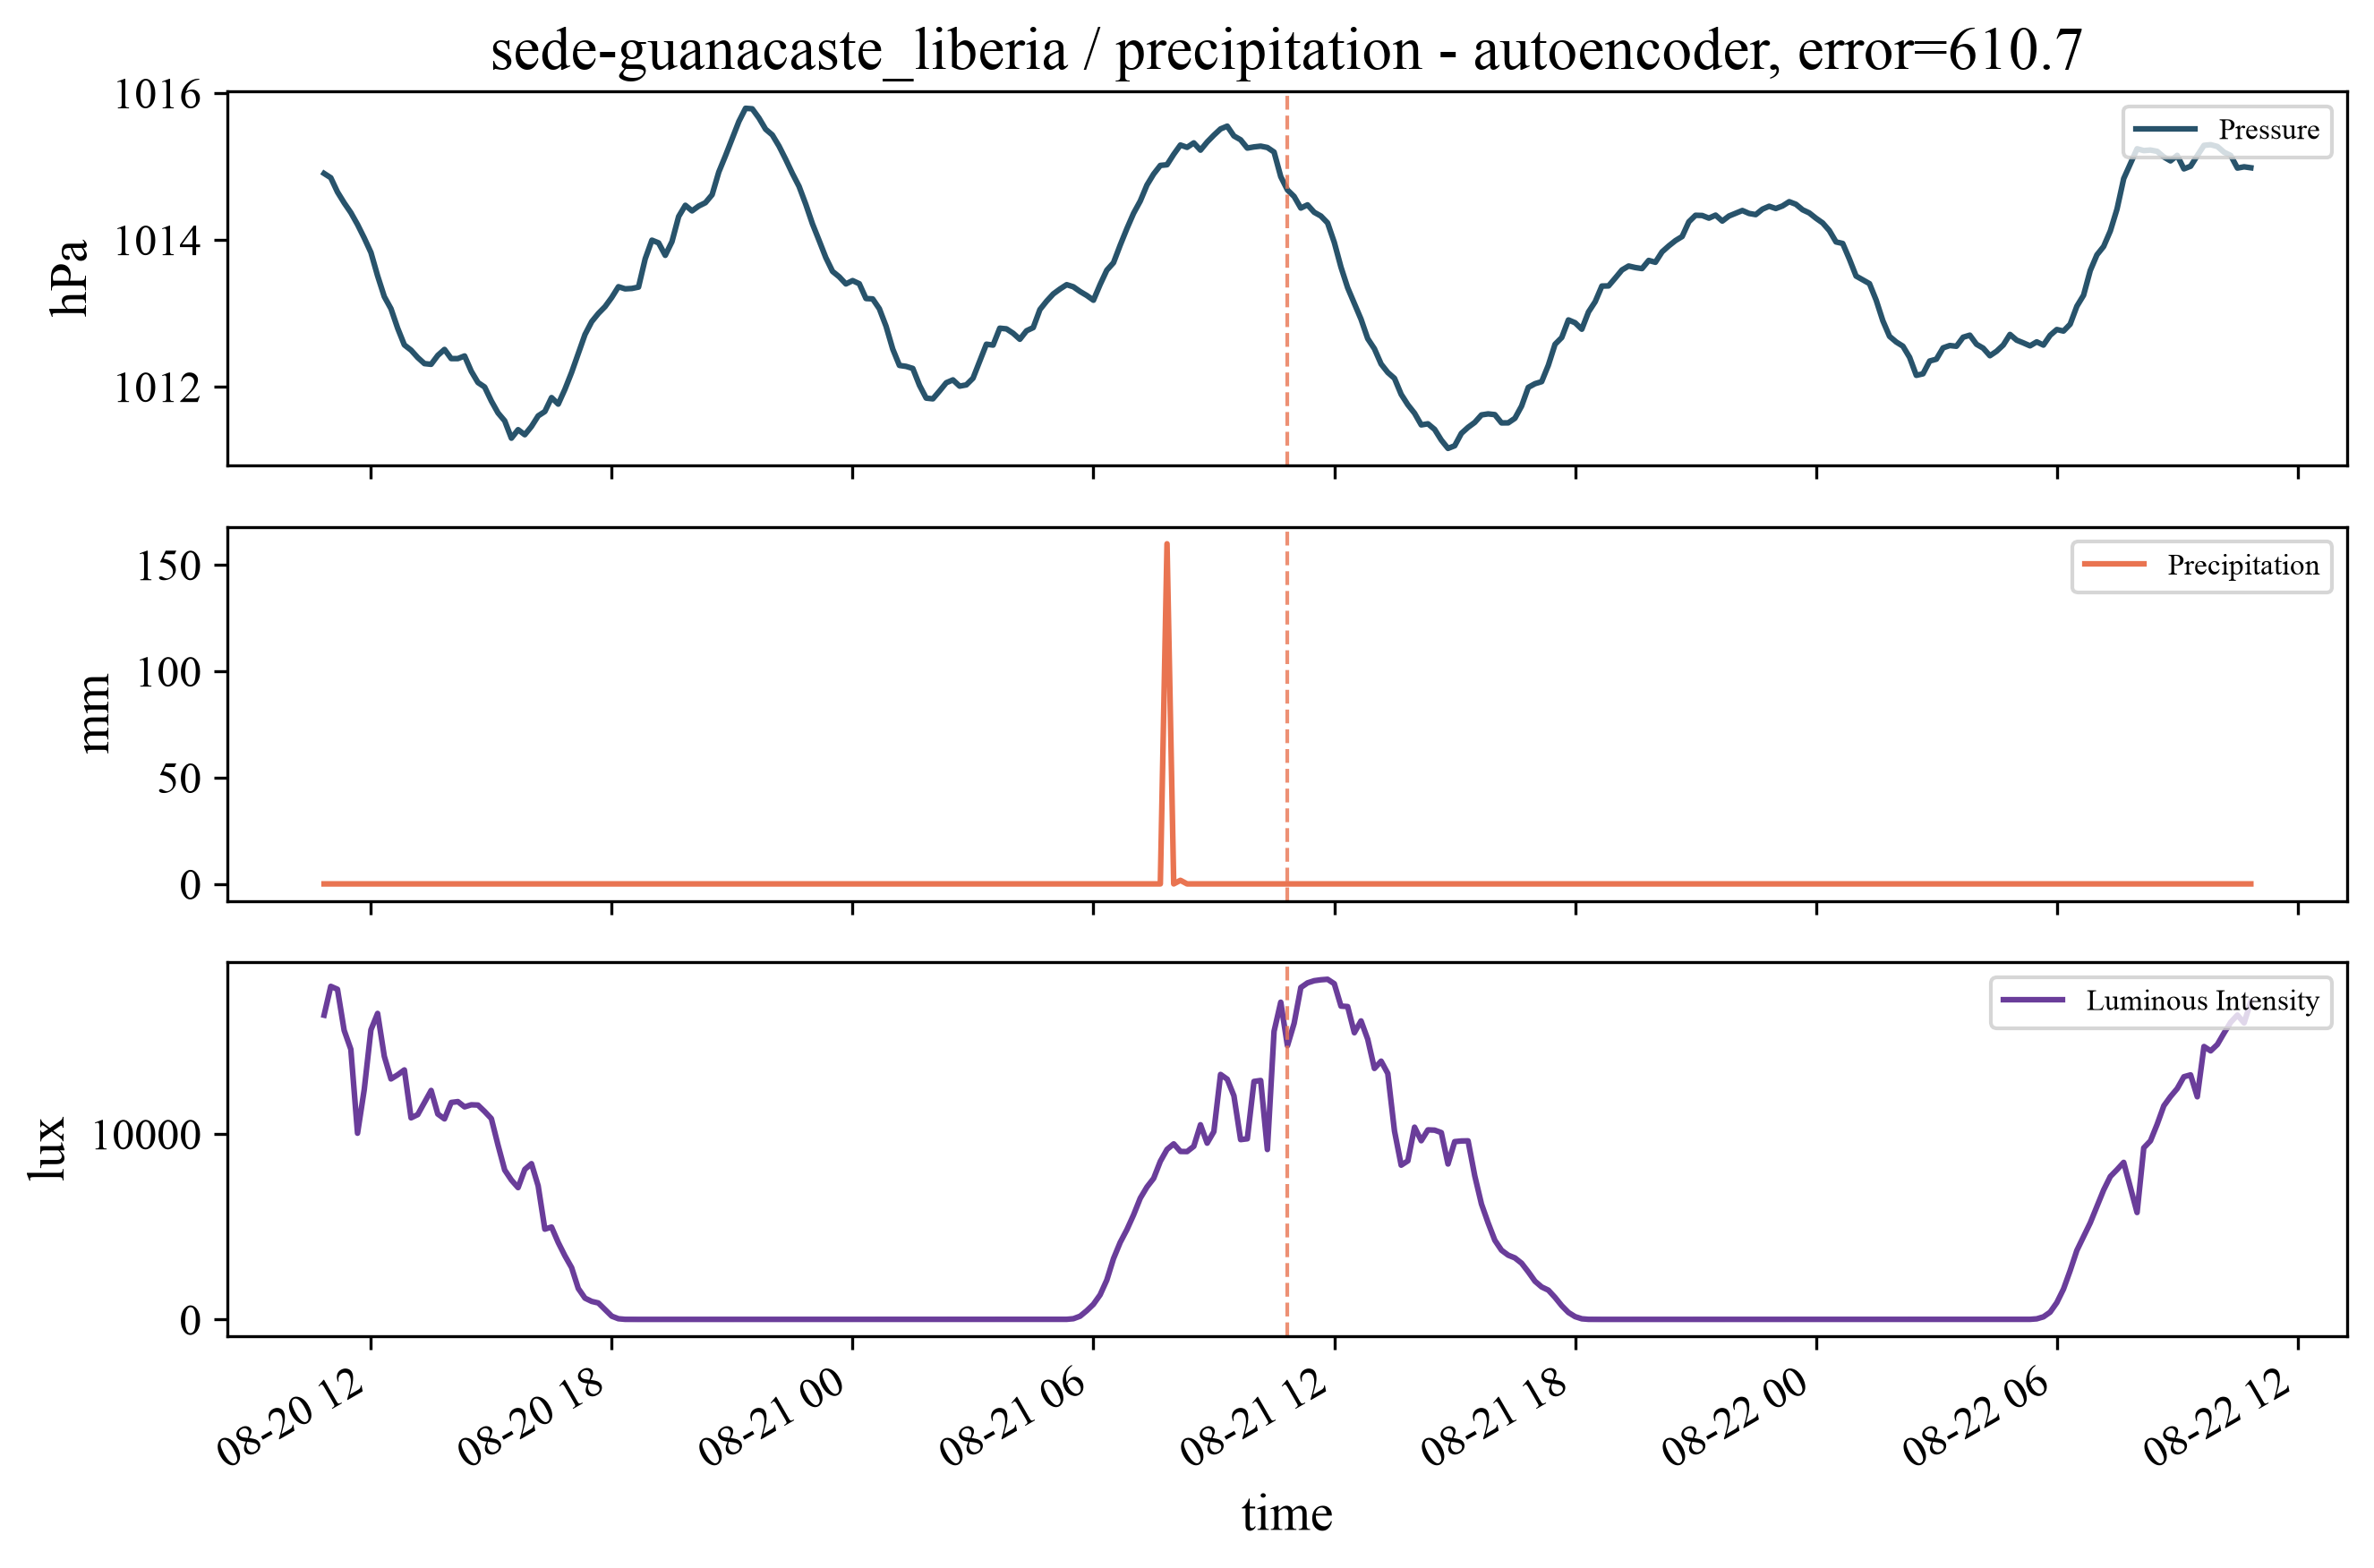

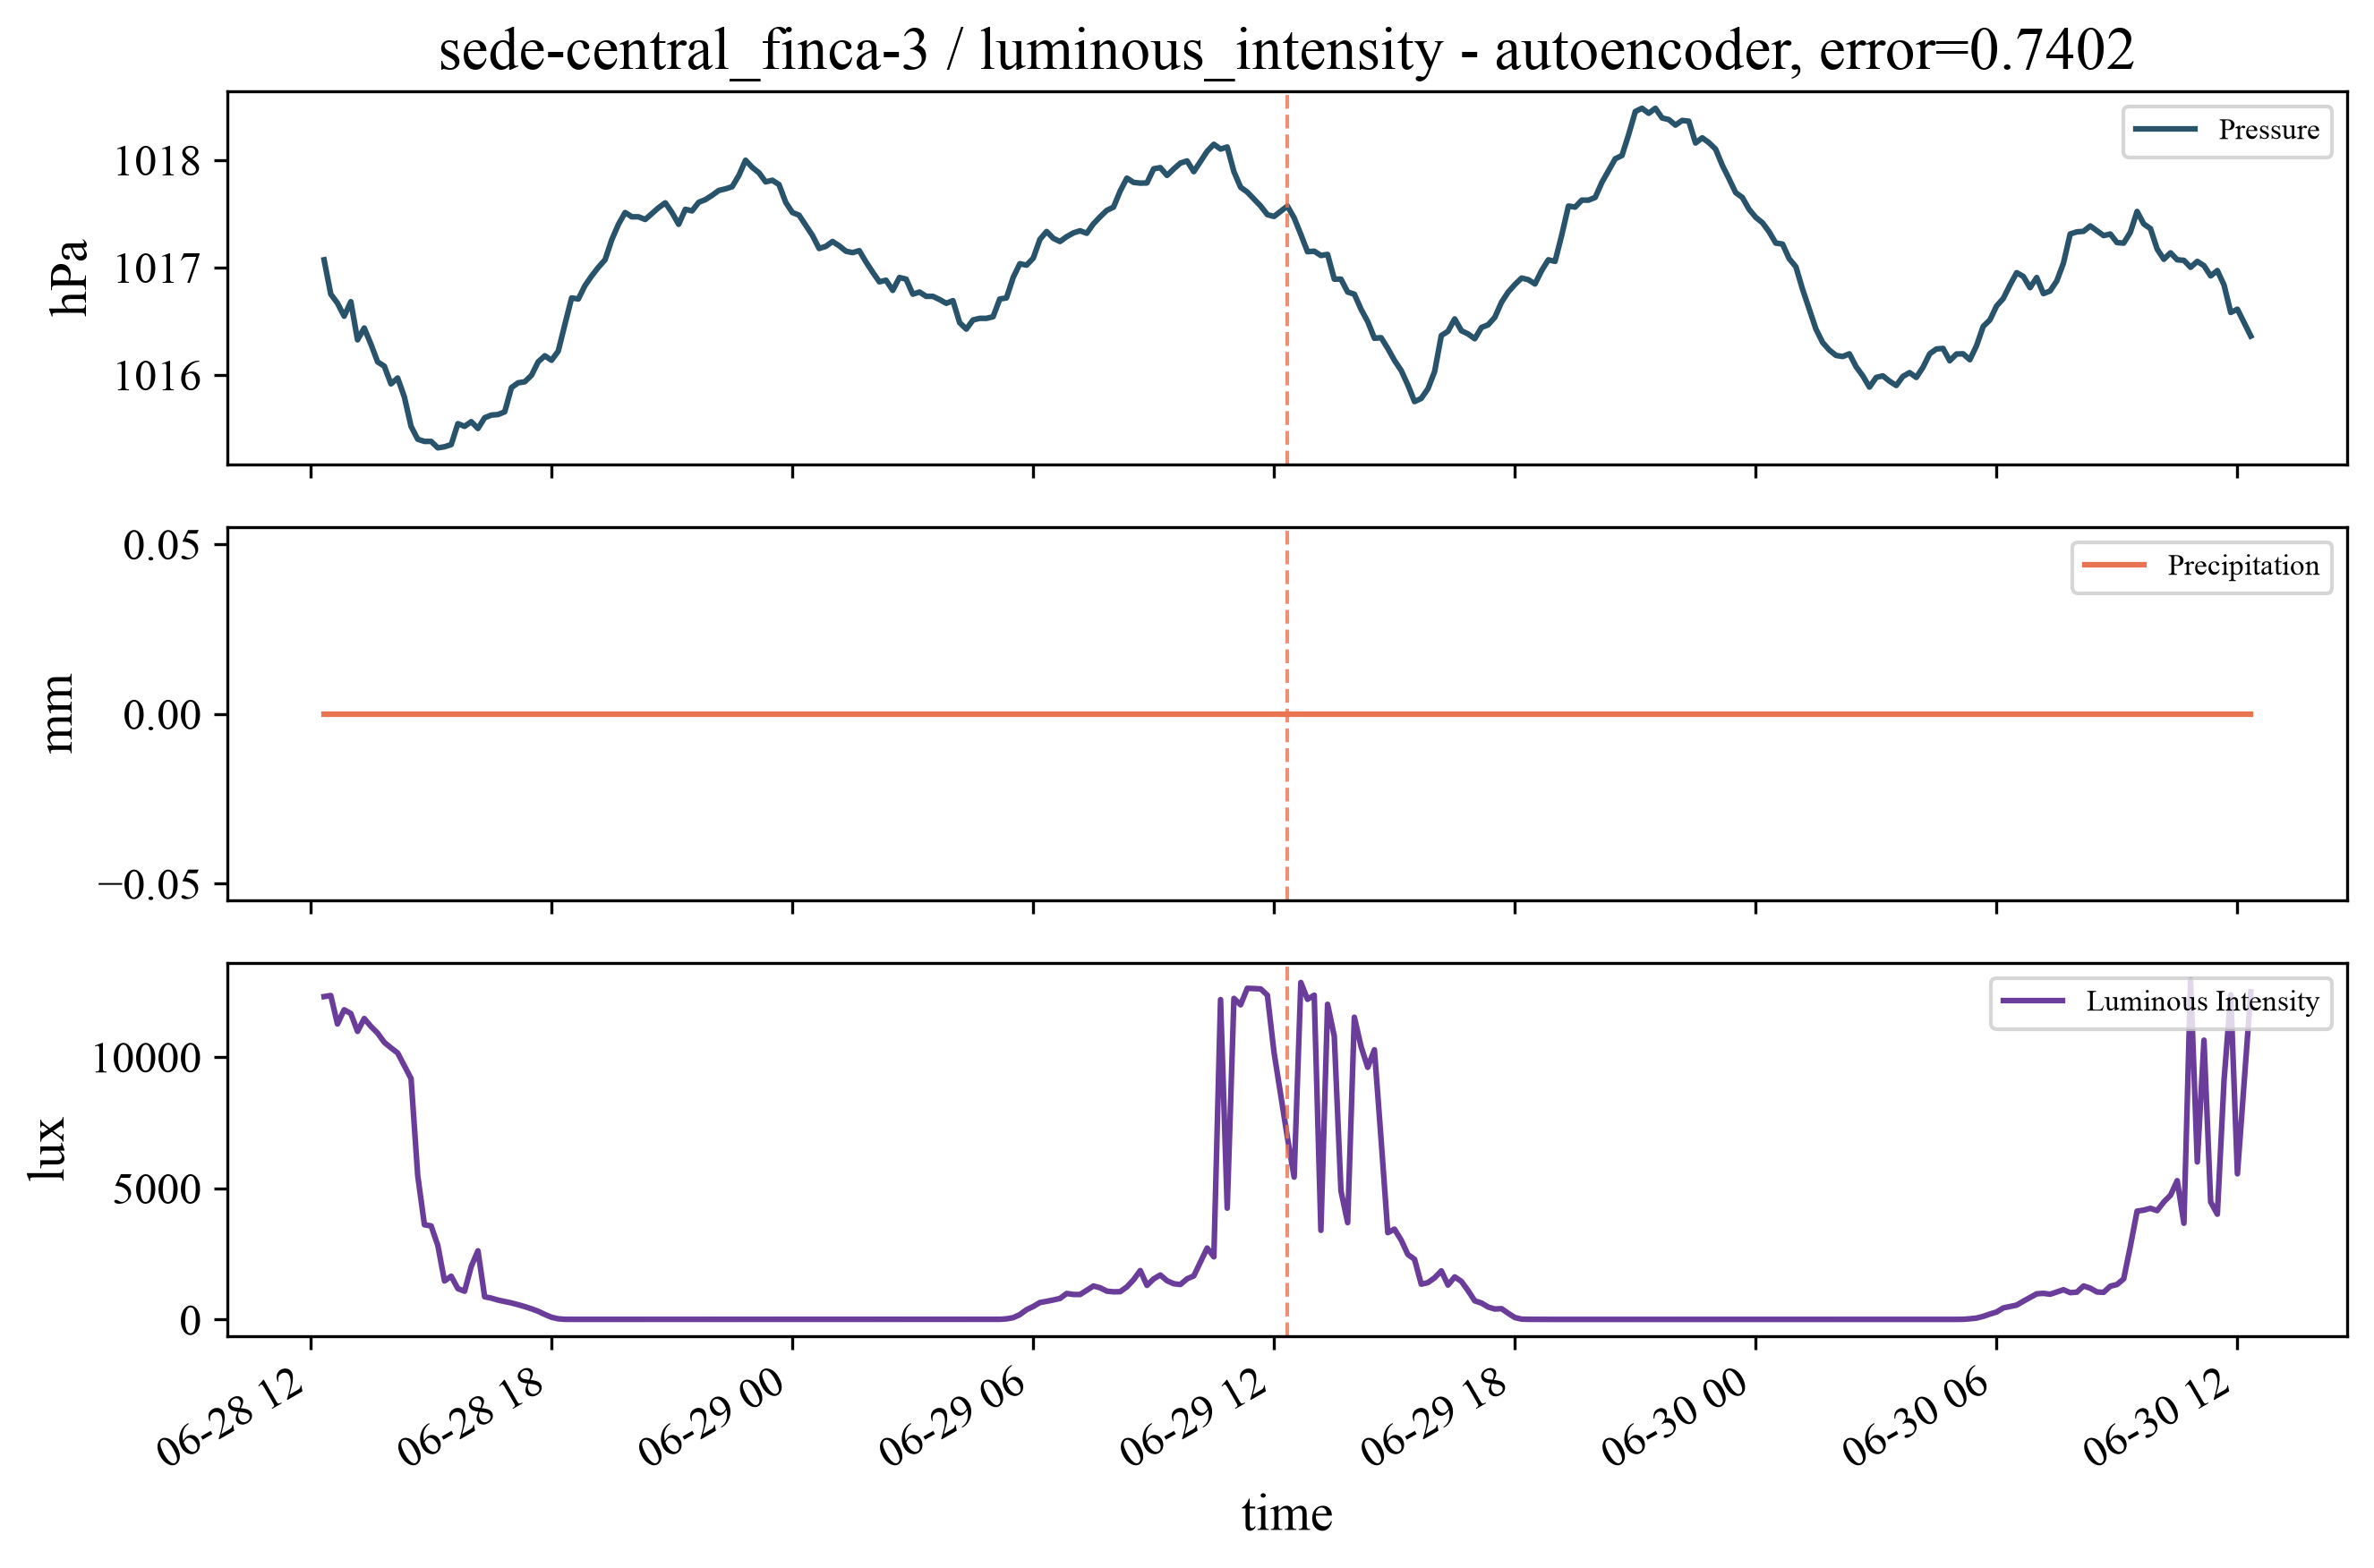

In [12]:
def plot_flagged(station, sensor, center, score, half_span=pd.Timedelta("24h")):
    df10 = station_frames[station]
    window = df10.loc[center - half_span : center + half_span]
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    cols = ["pressure", "precipitation", "luminous_intensity"]
    units = {"pressure": "hPa", "precipitation": "mm", "luminous_intensity": "lux"}
    for ax, col, color_name in zip(axes, cols, PALETTE_ORDER):
        ax.plot(window.index, window[col], color=PALETTE[color_name], label=pretty_label(col))
        ax.axvline(center, color=PALETTE["burnt_sienna"], linestyle="--", linewidth=1, alpha=0.8)
        ax.set_ylabel(units[col])
        ax.legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"{station} / {sensor} - autoencoder, error={score:.4g}")
    axes[-1].set_xlabel("time")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


top = (
    detections[detections["flagged"]]
    .sort_values("score", ascending=False)
    .groupby("sensor")
    .head(1)
)
for row in top.itertuples():
    fig = plot_flagged(row.station, row.sensor, row.timestamp, row.score)
    fig.savefig(DETECT_DIR / f"step5_top_flagged_{row.sensor}.png", bbox_inches="tight")
    plt.show()

## Closing note

Three of the five method families are now on disk in the shared schema
(`step3_zscore_family.parquet`, `step4_density_isolation.parquet`,
`step5_autoencoder.parquet`). Nothing here is validated against ground truth,
and the flagged rate above is not evidence about how many real anomalies
exist — with a percentile cutoff it is, by construction, whatever percentile
was chosen.

Three things from this step carry into Steps 6 and 7:

- **The threshold asymmetry.** This is the first method in the roster whose
  cutoff is not a published convention. Step 7's native-threshold view must
  say so rather than reading this method's flagged rate as a property of the
  method the way Step 4's Isolation Forest rate was.
- **Window and architecture are now fixed for Step 6.** 36 bins, the same
  prepared data, the same split, scaler, optimizer and stopping rule, all in
  `uema.reconstruct` — Step 6 adds recurrent classes and changes nothing
  else, which is what makes the recurrence comparison clean.
- **The robustness numbers bound what Step 5 can be claimed to show.** The
  bottleneck and seed passes say how much of this flagged set is the method
  rather than one arbitrary configuration of it, and the window control gives
  the figure comparable to Step 4b's LOF 0.053 and Isolation Forest 0.242.